In [ ]:
!pip install sentence-transformers transformers torch nltk scikit-learn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mord

  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=9383c11b63ccacc85468a2a1e60fcfed8e9d9d114fab57a1dc061748675f4b62
  Stored in directory: /root/.cache/pip/wheels/80/3e/3b/13f1adf346cad0fec675db328e4b0d814795c6c8e2fb659122
Successfully built mord


In [ ]:
!pip install language-tool-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 2.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- MODEL PERFORMANCE SUMMARY ---
             Metric     Train      Test
      Band Accuracy 97.270246 97.230085
  QWK (Reliability)  0.722376  0.711803
Pearson Correlation  0.786506  0.768991
        MSE (Error)  0.409654  0.438700


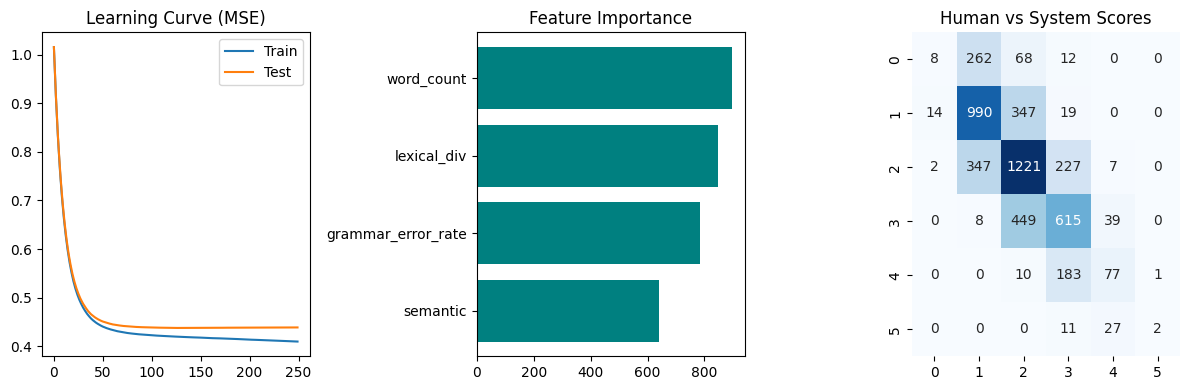

In [ ]:
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, mean_squared_error, confusion_matrix
from scipy.stats import pearsonr
from scipy.special import logsumexp
import lightgbm as lgb
import language_tool_python


DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/ASAP2_train_sourcetexts.csv"
TEXT_COL = "full_text"
SCORE_COL = "score"
SOURCE_COLS = ["source_text_1", "source_text_2", "source_text_3", "source_text_4"]

def clean(text):
    if pd.isna(text): return ""
    return str(text).lower().strip()

df["essay"] = df[TEXT_COL].apply(clean)
for c in SOURCE_COLS: df[c] = df[c].fillna("").apply(clean)
df[SCORE_COL] = df[SCORE_COL].astype(int)

device = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def get_semantic_score(row):
    essay_sents = re.split(r"(?<=[.!?])\s+", row["essay"])[:60]
    if not essay_sents or essay_sents == [""]: return 0
    e_embs = encoder.encode(essay_sents, convert_to_tensor=True)
    src_scores = []
    for c in SOURCE_COLS:
        if row[c]:
            s_emb = encoder.encode([row[c]], convert_to_tensor=True)
            sims = util.cos_sim(e_embs, s_emb).squeeze(1).cpu().numpy()
            src_scores.append(logsumexp(sims))
    return np.mean(src_scores) if src_scores else 0

df["semantic"] = df.apply(get_semantic_score, axis=1)
tool = language_tool_python.LanguageTool("en-US")
df["word_count"] = df["essay"].apply(lambda x: len(x.split()))
df["grammar_errors"] = df["essay"].apply(lambda x: len(tool.check(x)))
df["grammar_error_rate"] = df["grammar_errors"] / (df["word_count"] + 1e-6)
df["lexical_div"] = df["essay"].apply(lambda x: len(set(x.split())) / (len(x.split()) + 1e-6))
tool.close()

features = ["semantic", "word_count", "lexical_div", "grammar_error_rate"]
X = df[features]
y = df[SCORE_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = lgb.LGBMRegressor(verbose=-1,n_estimators=250, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
          eval_names=["Train", "Test"], eval_metric="mse", callbacks=[lgb.log_evaluation(period=0)])

y_train_pred = np.clip(np.rint(model.predict(X_train)), 0, 10).astype(int)
y_test_pred = np.clip(np.rint(model.predict(X_test)), 0, 10).astype(int)

metrics_data = {
    "Metric": ["Band Accuracy","QWK (Reliability)", "Pearson Correlation", "MSE (Error)"],
    "Train": [np.mean(np.abs(y_train - y_train_pred) <= 1) * 100,cohen_kappa_score(y_train, y_train_pred, weights="quadratic"),
              pearsonr(y_train, model.predict(X_train))[0],
              mean_squared_error(y_train, model.predict(X_train))],
    "Test": [np.mean(np.abs(y_test - y_test_pred) <= 1) * 100,cohen_kappa_score(y_test, y_test_pred, weights="quadratic"),
             pearsonr(y_test, model.predict(X_test))[0],
             mean_squared_error(y_test, model.predict(X_test))]
}
print("\n--- MODEL PERFORMANCE SUMMARY ---")
print(pd.DataFrame(metrics_data).to_string(index=False))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(model.evals_result_['Train']['l2'], label='Train')
plt.plot(model.evals_result_['Test']['l2'], label='Test')
plt.title('Learning Curve (MSE)')
plt.legend()

plt.subplot(1, 3, 2)
fi = pd.DataFrame({"F": features, "I": model.feature_importances_}).sort_values("I")
plt.barh(fi["F"], fi["I"], color='teal')
plt.title('Feature Importance')

plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Human vs System Scores')
plt.tight_layout()
plt.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Loaded ML grammar scores
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[800]	valid_0's l2: 0.431934
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[800]	valid_0's l2: 0.431934

════════ TRAIN ════════
97.50419876655545 0.7317963386560329 0.7861743367365444 0.4107817118889921

════════ TEST ════════
97.23008491710473 0.7045990219032303 0.7734577941046636 0.4319341016437701


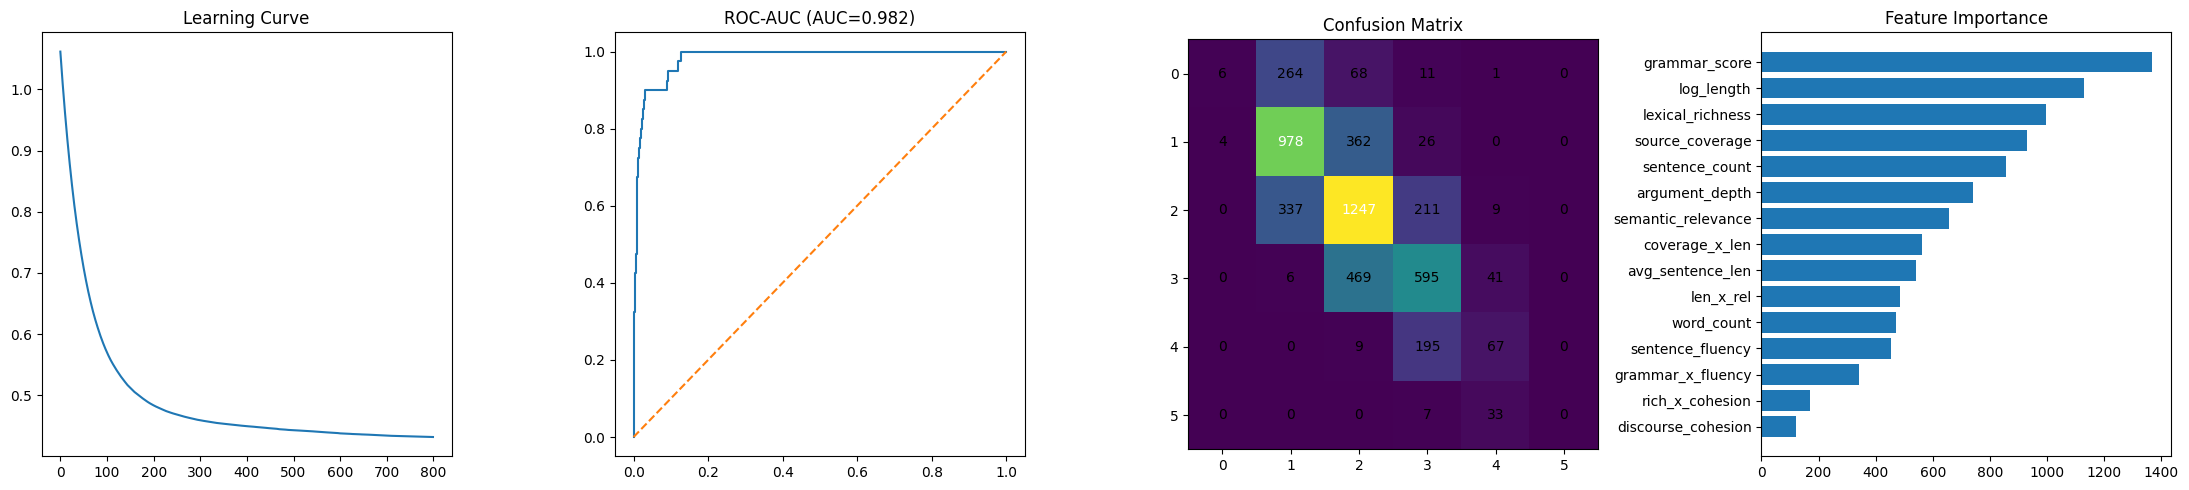

In [ ]:
import re
import os
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import lightgbm as lgb
import language_tool_python
import matplotlib.pyplot as plt
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/ASAP2_train_sourcetexts.csv"
CACHE_PATH = "/content/drive/MyDrive/Colab Notebooks/cache/"
os.makedirs(CACHE_PATH, exist_ok=True)
SOURCE_COLS = ["source_text_1","source_text_2","source_text_3","source_text_4"]
def clean(x):
    if pd.isna(x): return ""
    return str(x).lower().strip()
df = pd.read_csv(DATA_PATH, engine="python", on_bad_lines="skip")
df["essay"] = df["full_text"].apply(clean)
for c in SOURCE_COLS:
    df[c] = df[c].fillna("").apply(clean)
df["score"] = df["score"].astype(int)
device  = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer("all-MiniLM-L6-v2", device=device)
def load_or_encode(texts, path):
    if os.path.exists(path):
        return np.load(path)
    emb = encoder.encode(texts, batch_size=128, show_progress_bar=True)
    np.save(path, emb)
    return emb
essay_emb = load_or_encode(df["essay"].tolist(), CACHE_PATH + "essay.npy")
src_emb = {}
for c in SOURCE_COLS:
    src_emb[c] = load_or_encode(df[c].tolist(), CACHE_PATH + f"{c}.npy")
import numpy as np
import re
import os
GRAMMAR_PATH = "/content/drive/MyDrive/Colab Notebooks/cache/grammar_ml.npy"

def split_sentences(text):
    return [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

def compute_grammar_scores(texts, encoder):
    scores = []
    for text in texts:
        sentences = split_sentences(text)
        if len(sentences) <= 1:
            scores.append(0.0)
            continue
        emb = encoder.encode(sentences)

        var = np.mean(np.var(emb, axis=0))

        score = 1 / (1 + var)
        scores.append(score)
    return np.array(scores)

if os.path.exists(GRAMMAR_PATH):
    print(" Loaded ML grammar scores")
    grammar_scores = np.load(GRAMMAR_PATH)

else:
    print(" Computing ML grammar scores")
    grammar_scores = compute_grammar_scores(df["essay"].tolist(), encoder)
    np.save(GRAMMAR_PATH, grammar_scores)

def cos_batch(A, B):
    return np.sum(A * B, axis=1) / (
        np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-6)

df["semantic_relevance"] = np.mean(
    np.vstack([cos_batch(essay_emb, src_emb[c]) for c in SOURCE_COLS]), axis=0)
df["source_coverage"] = np.max(
    np.vstack([cos_batch(essay_emb, src_emb[c]) for c in SOURCE_COLS]), axis=0)
df["semantic_relevance"] = df["semantic_relevance"].clip(0,1)
df["source_coverage"]    = df["source_coverage"].clip(0,1)

words = df["essay"].str.split()
df["word_count"] = words.str.len()

sents = df["essay"].str.count(r'[.!?]+').clip(lower=1)
df["sentence_count"] = sents

df["log_length"] = np.log1p(df["word_count"])

df["avg_sentence_len"] = df["word_count"] / (sents + 1e-6)

df["lexical_richness"] = words.apply(
    lambda w: len(set(w)) / np.sqrt(len(w)+1e-6) if w else 0)


df["grammar_score"] = grammar_scores


df["sentence_fluency"] = df["essay"].apply(
    lambda x: np.std([len(s.split())
                      for s in re.split(r'[.!?]+', x) if s.strip()])
    if x else 0)


CONNECTIVES = {"however","therefore","moreover","although",
               "consequently","furthermore","nevertheless","thus"}
df["discourse_cohesion"] = words.apply(
    lambda w: sum(tok in CONNECTIVES for tok in w)/(len(w)+1e-6)
    if w else 0)


df["argument_depth"] = (
    df["essay"].str.count(",") +
    df["essay"].str.count(r'\b(and|but|because|if|when|although|while)\b')
) / sents
df["len_x_rel"] = df["log_length"] * df["semantic_relevance"]
df["rich_x_cohesion"] = df["lexical_richness"] * df["discourse_cohesion"]
df["grammar_x_fluency"] = df["grammar_score"] * df["sentence_fluency"]
df["coverage_x_len"] = df["source_coverage"] * df["log_length"]
FEATURES = [
    "semantic_relevance",
    "source_coverage",
    "log_length",
    "word_count",
    "sentence_count",
    "avg_sentence_len",
    "lexical_richness",
    "grammar_score",
    "sentence_fluency",
    "discourse_cohesion",
    "argument_depth",
    "len_x_rel",
    "rich_x_cohesion",
    "grammar_x_fluency",
    "coverage_x_len"
]
X = df[FEATURES].values
y = df["score"].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
X_train_df = pd.DataFrame(X_train, columns=FEATURES)
X_test_df  = pd.DataFrame(X_test, columns=FEATURES)
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.01,
    num_leaves=16,
    max_depth=4,
    min_data_in_leaf=80,
    lambda_l1=2.0,
    lambda_l2=2.0,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    verbose=-1,
)

model.fit(
    X_train_df, y_train,
    eval_set=[(X_test_df, y_test)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(50)]
)
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.01,
    num_leaves=16,
    max_depth=4,
    min_data_in_leaf=80,
    lambda_l1=2.0,
    lambda_l2=2.0,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    verbose=-1,
)
model.fit(
    X_train_df, y_train,
    eval_set=[(X_test_df, y_test)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(50)]
)
from sklearn.metrics import cohen_kappa_score, mean_squared_error
from scipy.stats import pearsonr
import numpy as np
def round_clip(pred):
    return np.clip(np.rint(pred), y.min(), y.max()).astype(int)

def compute_metrics(y_true, pred):
    pred_r = round_clip(pred)

    band = np.mean(np.abs(y_true - pred_r) <= 1) * 100
    qwk = cohen_kappa_score(y_true, pred_r, weights="quadratic")
    r,_ = pearsonr(y_true, pred)
    mse = mean_squared_error(y_true, pred)

    return band, qwk, r, mse, pred_r


train_pred = model.predict(X_train_df)
train_band, train_qwk, train_r, train_mse, train_pred_r = compute_metrics(y_train, train_pred)


test_pred = model.predict(X_test_df)
test_band, test_qwk, test_r, test_mse, test_pred_r = compute_metrics(y_test, test_pred)

print("\n════════ TRAIN ════════")
print(train_band, train_qwk, train_r, train_mse)
print("\n════════ TEST ════════")
print(test_band, test_qwk, test_r, test_mse)

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(22,5))


axes[0].plot(model.evals_result_["valid_0"]["l2"])
axes[0].set_title("Learning Curve")


classes = sorted(np.unique(y))
y_bin = label_binarize(y_test, classes=classes)
fpr, tpr, _ = roc_curve(y_bin[:, -1], test_pred)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr)
axes[1].plot([0,1],[0,1],'--')
axes[1].set_title(f"ROC-AUC (AUC={roc_auc:.3f})")

cm = confusion_matrix(y_test, test_pred_r)
axes[2].imshow(cm)
axes[2].set_title("Confusion Matrix")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i,j] > cm.max()/2 else "black"
        axes[2].text(j, i, cm[i,j], ha="center", va="center", color=color)

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
axes[3].barh(imp.index, imp.values)
axes[3].set_title("Feature Importance")
plt.tight_layout()
plt.show()
